# Z01: Token Propensities Analysis


This notebook contains the analysis of Token Propensities. This is the second analysis of first Scribal Intent Study (Z01).

## Setup and Utility Functions

In [1]:
# Imports and setup
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML
import os

from qlynx.file_utils import load_pkl
from qlynx.stats_utils import *
from qlynx.display_utils import render_html_to_image
from voynichlib.utils import display_voynichese

%reload_ext autoreload
%autoreload 2
 

# Set Global Parameters

In [2]:
do_parametric_studies = True
MAX_BAYES = np.exp(10)
MAX_PROPENSITY = 999
THRESHOLDS = {
    'p_value': 0.01,
    'ln_bayes_factor': 5
}
THRESHOLDS['bayes_factor'] = np.exp(THRESHOLDS['ln_bayes_factor'])
reference_cohort = 'MIDDLE'
# smooth = 'laplace'
# smooth = 'laplace'
smooth = None



## Load the Token Cohort Data

In [3]:
file_path = 'voynich_data/outputs/token_cohort_data.pkl'
token_cohort_data = load_pkl(file_path)

cohorts = token_cohort_data['cohorts']
cohorts_with_randoms = token_cohort_data['cohorts_with_randoms']

corpus_by_c = token_cohort_data['corpus_by_c']
pmfs_by_c = token_cohort_data['pmfs_by_c']
token_ws_by_c = token_cohort_data['token_ws_by_c']

glyph_pmfs_by_c = token_cohort_data['glyph_pmfs_by_c']
glyphs_by_c = token_cohort_data['glyphs_by_c']

In [4]:
glyph_pmfs_by_c.keys()

dict_keys(['ALL', 'MIDDLE', 'TOP', 'FIRST', 'LAST', 'BEFORE', 'AFTER', 'SECOND', 'FOURTH'])

## Get Token Lengths for the Most Frequent Tokens

In [5]:
def get_top_vocabulary_tokens_lengths_dict(cohort, N_v:int=None):
    tokens = pmfs_by_c[cohort].values
    if not N_v:
        tokens = tokens[:N_v]
    token_lengths_dict = {}
    df = corpus_by_c[cohort].tokens_df()
    for token in tokens:
        df_token = df[df['token'] == token]
        token_length = df_token['token_length_min'].iloc[0]
        token_lengths_dict[token] = token_length
        pass
    pass
    return token_lengths_dict

## Function to Compile DataFrame for a Cohort

In [6]:
def compile_token_propensity_df(target_cohort, reference_cohort, p_value_threshold, bayes_threshold):
    top_token_length_dict = get_top_vocabulary_tokens_lengths_dict(reference_cohort)
    df = pd.DataFrame(columns = ['token', 'glyph_count', 'N_ref', 'n_ref', 'N_x', 'n_x', 'p_ref', 'p_x', 'p_value', 'sig_p_value', 'sig_BF', 'propensity', 'bayes', 'binom_stat_le', 'binom_stat_gt'])
    for token, w in top_token_length_dict.items():
        pmf_ref = pmfs_by_c[reference_cohort]
        N_ref = pmf_ref.total_count
        n_ref = pmf_ref.count(token) if N_ref > 0 else 0
        p_ref = pmf_ref.prob(token, smooth=smooth)

        pmf_x = pmfs_by_c[target_cohort]                        
        N_x = pmf_x.total_count
        n_x = pmf_x.count(token) if N_x > 0 else 0
        p_x = pmf_x.prob(token, smooth=smooth)

        p_value = calculate_binomial_probability(n_x, N_x, p_ref)

        # if n_x == 0:
        #     bayes_factor = 1/MAX_BAYES
        # else:
        #     bayes_factor = bayes_factor_binomial(n_x, N_x, p_x, p_ref)
        #     bayes_factor = min(MAX_BAYES, bayes_factor)
        bayes_factor = bayes_factor_binomial(n_x, N_x, p_x, p_ref)
        bayes_factor = min(MAX_BAYES, bayes_factor)

        binom_stat_le =  binom.cdf(n_x, N_x, p_ref)        
        binom_stat_gt =  binom.cdf(n_x, N_x, 1. -p_ref)        

        if target_cohort.startswith('Rand'):
            propensity = 1.
        else: 
            # if p_x ==  0.:
            #     propensity = -MAX_PROPENSITY
            # else:
            #     propensity = p_x/p_ref  if p_ref > 0 else MAX_PROPENSITY
            #     # propensity = np.log(p_x/p_ref)  if p_ref > 0 else MAX_PROPENSITY
            # pass
            propensity = p_x/p_ref  if p_ref > 0 else MAX_PROPENSITY
            pass
        verdict_p_value = p_value < p_value_threshold
        verdict_bayes_factor = bayes_factor > bayes_threshold
        df.loc[len(df)] = [token,
                           top_token_length_dict[token],
                           N_ref,
                           n_ref,
                           N_x,
                           n_x,
                           p_ref,
                           p_x,
                           p_value,
                           verdict_p_value,
                           verdict_bayes_factor,
                           np.round(propensity,1),
                           bayes_factor,
                          binom_stat_le,
                          binom_stat_gt]
        pass
    df.set_index('token', inplace=True)
    pass
    return df

def compile_glyph_propensity_df(target_cohort, reference_cohort, p_value_threshold, bayes_threshold):
    top_token_length_dict = get_top_vocabulary_tokens_lengths_dict(reference_cohort)
    df = pd.DataFrame(columns = ['glyph',  'N_ref', 'n_ref', 'N_x', 'n_x', 'p_ref', 'p_x',  'p_value', 'sig_p_value', 'sig_BF', 'propensity', 'bayes', 'binom_stat_le', 'binom_stat_gt'])
    glyphs = set(glyphs_by_c['ALL'])
    
    for glyph in glyphs:
        pmf_ref = glyph_pmfs_by_c[reference_cohort]
        N_ref = pmf_ref.total_count
        n_ref = pmf_ref.count(glyph) if N_ref > 0 else 0
        p_ref = pmf_ref.prob(glyph, smooth=smooth)
        if p_ref == 0:
            continue

        pmf_x = glyph_pmfs_by_c[target_cohort]                        
        N_x = pmf_x.total_count
        n_x = pmf_x.count(glyph)  if N_x > 0 else 0
        p_x = pmf_x.prob(glyph, smooth=smooth)
        
        p_value = calculate_binomial_probability(n_x, N_x, p_ref)

        if n_x == 0:
            bayes_factor = 1/MAX_BAYES
        else:
            bayes_factor = bayes_factor_binomial(n_x, N_x, p_x, p_ref)
            bayes_factor = min(MAX_BAYES, bayes_factor)
        bayes_factor = int(bayes_factor)
        binom_stat_le =  binom.cdf(n_x, N_x, p_ref)        
        binom_stat_gt =  binom.cdf(n_x, N_x, 1. -p_ref)        

        if p_x ==  0.:
            propensity = -MAX_PROPENSITY
        else:
            propensity = p_x/p_ref  if p_ref > 0 else MAX_PROPENSITY
            # propensity = np.log(p_x/p_ref)  if p_ref > 0 else MAX_PROPENSITY
        pass        
            
        verdict_p_value = p_value <= p_value_threshold
        verdict_bayes_factor = bayes_factor >= bayes_threshold

        df.loc[len(df)] = [glyph,
                           N_ref,
                           n_ref,
                           N_x,
                           n_x,
                           p_ref,
                           p_x,
                           p_value,
                           verdict_p_value,
                           verdict_bayes_factor,
                           np.round(propensity,1),
                           bayes_factor,
                          binom_stat_le,
                          binom_stat_gt]
        pass
    df.set_index('glyph', inplace=True)
    pass
    return df

## Threshold Parametric Study

In [7]:
styles = {
    'ALL':['grey','-',1],
    'MIDDLE':['red','-',1],
    'TOP':['red','-.',1],
    'FIRST':['green','-',2],
    'SECOND':['orange','-.',2],
    'THIRD':['orange','-.',2],
    'FOURTH':['orange','-.',2],
    'BEFORE':['blue','--',2],
    'AFTER':['blue','--',1],
    'LAST':['green','-',1],
    'RAND 1':['grey',':',1],
    'RAND 2':['grey',':',1], 
    'RAND 3':['grey',':',1],
    'RAND 4':['grey',':',1],
    'RAND 5':['grey',':',1],
    'RAND 6':['grey',':',1],
}        

p_thresholds_x = [10,9,8,7,6,5,4,3,2]
p_thresholds1 = [.01*x for x in p_thresholds_x]
p_thresholds2 = [.001*x for x in p_thresholds_x]
p_thresholds3 = [.0001*x for x in p_thresholds_x]
p_thresholds4 = [.00001*x for x in p_thresholds_x]
p_thresholds = p_thresholds1 + p_thresholds2 + p_thresholds3 + p_thresholds4

bayes_thresholds_x = [1,2,3,4,5,6,7,8,9]
bayes_thresholds1 = [1*x for x in bayes_thresholds_x]
bayes_thresholds2 = [10*x for x in bayes_thresholds_x]
bayes_thresholds3 = [100*x for x in bayes_thresholds_x]
bayes_thresholds4 = [1000*x for x in bayes_thresholds_x]
bayes_thresholds = bayes_thresholds1 + bayes_thresholds2 + bayes_thresholds3 + bayes_thresholds4


In [8]:
def plot_threshold_parametric_data(stat_type, tokens_as_list, filename:str = None):   
    for cohort in cohorts_with_randoms:
        if cohort=='ALL':
            continue
        if cohort=='MIDDLE':
            continue
        if stat_type == 'p_value':
            plt.plot(p_thresholds, 
                 tokens_as_list[cohort].values(), 
                 label=cohort, 
                 color=styles[cohort][0], 
                 linestyle=styles[cohort][1], 
                 linewidth=styles[cohort][2])
        elif stat_type == 'bayes':
            plt.plot(bayes_thresholds, 
                     tokens_as_list[cohort].values(), 
                     label=cohort, 
                     color=styles[cohort][0], 
                     linestyle=styles[cohort][1], 
                     linewidth=styles[cohort][2])
        pass
    plt.legend()
    if stat_type == 'p_value':
        plt.xlabel('p-value Threshold')
        plt.ylim((0,50))
        plt.xlim((0,0.1))
        threshold = THRESHOLDS['p_value']
    elif stat_type == 'bayes':
        plt.xlabel('B Threshold')
        plt.xscale('log')
        plt.ylim((0,50))
        plt.xlim((3,10000))
        threshold = THRESHOLDS['bayes_factor']
    pass
    plt.axvline(x=threshold, color='r', linestyle='--')
    plt.ylabel('Count of Tokens with Significant Propensity')
    if filename:
        plt.savefig(filename,  bbox_inches='tight')
    # plt.xscale('log')
    # plt.yscale('log')
    plt.show()


In [9]:
def compile_threshold_parametic_data(stat_type, use_both_thresholds:bool=False):
    print(f"Parametric Study of {stat_type}")
    num_propensity_tokens_by_cohort_and_threshold = {}
    for cohort in cohorts_with_randoms:
        if cohort=='ALL':
            continue
        print(f"\t{cohort}")
        num_propensity_tokens_by_cohort_and_threshold[cohort] = {}
        if stat_type == 'p_value':
            for _p_value_threshold in p_thresholds:
                df = compile_token_propensity_df(cohort, reference_cohort, _p_value_threshold, THRESHOLDS['bayes_factor'])
                if use_both_thresholds:
                    token_propensity_df = df[(df['sig_p_value']) & (df['sig_BF'])]
                else:
                    token_propensity_df = df[(df['sig_p_value'])]
                num_propensity_tokens_by_cohort_and_threshold[cohort][_p_value_threshold] = len(token_propensity_df)
                pass
        elif stat_type == 'bayes':
            for _bayes_threshold in bayes_thresholds:
                df = compile_token_propensity_df(cohort, reference_cohort, THRESHOLDS['p_value'], _bayes_threshold)
                if use_both_thresholds:
                    token_propensity_df = df[(df['sig_p_value']) & (df['sig_BF'])]
                else:
                    token_propensity_df = df[(df['sig_BF'])]
                num_propensity_tokens_by_cohort_and_threshold[cohort][_bayes_threshold] = len(token_propensity_df)
                pass
            pass
            
    pass
    return num_propensity_tokens_by_cohort_and_threshold


Parametric Study of p_value
	MIDDLE
	TOP
	FIRST
	LAST
	BEFORE
	AFTER
	SECOND
	FOURTH
	RAND 1
	RAND 2
	RAND 3
	RAND 4
	RAND 5
	RAND 6


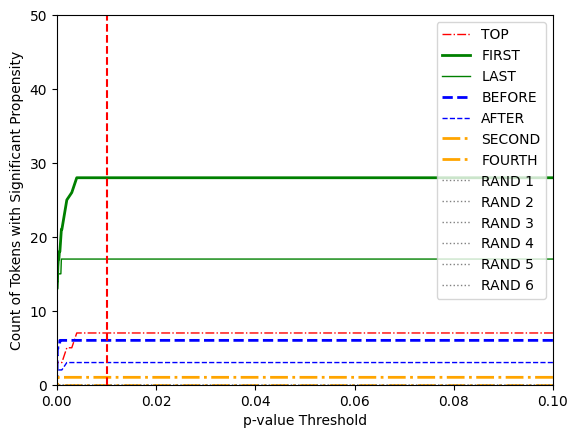

In [10]:
if do_parametric_studies:
    stat_type = 'p_value'
    num_propensity_tokens_p_value = compile_threshold_parametic_data(stat_type, use_both_thresholds=True) 
    plot_threshold_parametric_data(stat_type, 
                                   num_propensity_tokens_p_value)

Parametric Study of p_value
	MIDDLE
	TOP
	FIRST
	LAST
	BEFORE
	AFTER
	SECOND
	FOURTH
	RAND 1
	RAND 2
	RAND 3
	RAND 4
	RAND 5
	RAND 6


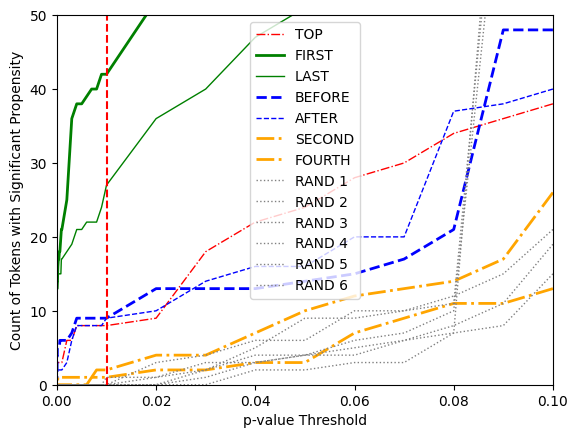

In [11]:
if do_parametric_studies:
    stat_type = 'p_value'
    num_propensity_tokens_p_value = compile_threshold_parametic_data(stat_type) 
    plot_threshold_parametric_data(stat_type, 
                                   num_propensity_tokens_p_value,  
                                   filename = 'voynich_data/outputs/F_Threshold_Parametric_p_values.png')

Parametric Study of bayes
	MIDDLE
	TOP
	FIRST
	LAST
	BEFORE
	AFTER
	SECOND
	FOURTH
	RAND 1
	RAND 2
	RAND 3
	RAND 4
	RAND 5
	RAND 6


FileNotFoundError: [Errno 2] No such file or directory: 'Analyses/Z001/F_Threshold_Parametric_bayes.png'

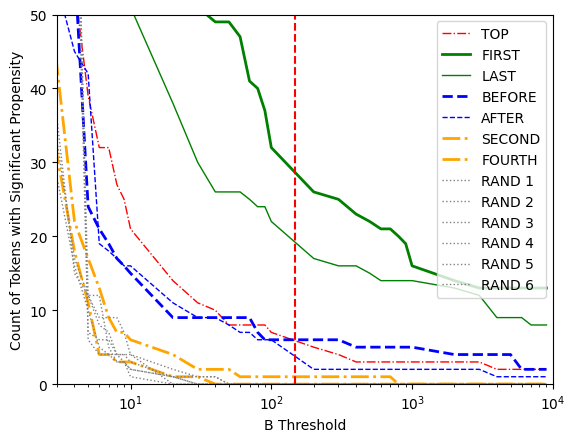

In [12]:
if do_parametric_studies:
    stat_type = 'bayes'
    num_propensity_tokens_bayes = compile_threshold_parametic_data(stat_type) 
    plot_threshold_parametric_data(stat_type, 
                                   num_propensity_tokens_bayes, 
                                   filename = 'Analyses/Z001/F_Threshold_Parametric_bayes.png')

## Create Summary DataFrames for each Cohort

### Token Propensity DataFrame

In [ ]:
token_propensity_dfs = {}
print(f"smoothing: {smooth}")
print(f"Summary Dataframes,   p_value_threshold= {THRESHOLDS['p_value']} , bayes_threshold={THRESHOLDS['bayes_factor']:.1f}")
N_tokens_df = pd.DataFrame(columns = ['cohort',  'N_p', 'N_p_af', 'N_p_av', 'N_b', 'N_b_af', 'N_b_av',  'N_either', 'N_both'])

for cohort in cohorts_with_randoms:
    if cohort == 'MIDDLE':
        continue
    token_propensity_dfs[cohort] = compile_token_propensity_df(cohort, 
                                                               reference_cohort, 
                                                               THRESHOLDS['p_value'], 
                                                               THRESHOLDS['bayes_factor'])
    df = token_propensity_dfs[cohort]
    N_p = len(df[ df['sig_p_value']])
    N_p_af =  len(df[ df['sig_p_value'] & (df['propensity']>0) ])
    N_p_av =  len(df[ df['sig_p_value'] & (df['propensity']<0) ])
    N_b = len(df[ df['sig_BF']])
    N_b_af =  len(df[ df['sig_BF'] & (df['propensity']>0) ])
    N_b_av =  len(df[ df['sig_BF'] & (df['propensity']<0) ])
    N_either =  len(df[ df['sig_BF'] | df['sig_p_value'] ])
    N_both =  len(df[ df['sig_BF'] & df['sig_p_value'] ])
    N_tokens_df.loc[len(N_tokens_df)] = [cohort,
                       N_p,
                       N_p_af,
                       N_p_av,
                       N_b,
                       N_b_af,
                       N_b_av,
                       N_either,
                       N_both]
                                             
    pass
    # print(80*'-')
pass
N_tokens_df

### Glyph Propensity DataFrame

In [ ]:
# p_threshold_glyphs = .01
# bayes_threshold_glyphs = 150
# glyph_propensity_dfs = {}
# print(f"smoothing: {smooth}")
# print(f"Summary Dataframes,   p_value_threshold= {p_threshold_glyphs} , bayes_threshold={bayes_threshold_glyphs}")
# count = 0
# N_glyphs_df = pd.DataFrame(columns = ['cohort',  'N_p', 'N_p_af', 'N_p_av', 'N_b', 'N_b_af', 'N_b_av',  'N_either', 'N_both'])
# for cohort in cohorts:
#     print(f"\t{cohort}")  
#     # for test_type in [ 'z-test']:
#     glyph_propensity_dfs[cohort] = compile_glyph_propensity_df(cohort, 
#                                                                reference_cohort, 
#                                                                THRESHOLDS['p_value'], 
#                                                            THRESHOLDS['bayes_factor'])
#     df = glyph_propensity_dfs[cohort]
#     N_p = len(df[ df['sig_p_value']])
#     N_p_af =  len(df[ df['sig_p_value'] & (df['propensity']>0) ])
#     N_p_av =  len(df[ df['sig_p_value'] & (df['propensity']<0) ])
#     N_b = len(df[ df['sig_BF']])
#     N_b_af =  len(df[ df['sig_BF'] & (df['propensity']>0) ])
#     N_b_av =  len(df[ df['sig_BF'] & (df['propensity']<0) ])
#     N_either =  len(df[ df['sig_BF'] | df['sig_p_value'] ])
#     N_both =  len(df[ df['sig_BF'] & df['sig_p_value'] ])
#     N_glyphs_df.loc[len(N_glyphs_df)] = [cohort,
#                        N_p,
#                        N_p_af,
#                        N_p_av,
#                        N_b,
#                        N_b_af,
#                        N_b_av,
#                        N_either,
#                        N_both]
#     pass
# pass
# N_glyphs_df

In [ ]:
def extract_df(cohort, stat_type, component_type):
    print(f"'{cohort}' Compared to 'MIDDLE'")
    if component_type == 'tokens':
        df = token_propensity_dfs[cohort]
    elif component_type == 'glyphs':
       df = glyph_propensity_dfs[cohort]

    if stat_type == 'p_value':
        df = df[df['sig_p_value']]
        df.sort_values(by='p_value', ascending=False)
    elif stat_type == 'bayes':
        df = df[df['sig_BF']]        
        df.sort_values(by='bayes', ascending=False)
    elif stat_type == 'both':
        df = df[(df['sig_p_value']) & (df['sig_BF'])]
        
    print(len(df))
    return df



In [ ]:
extract_df('SECOND', 'both', 'tokens')

In [ ]:
extract_df('TOP', 'both', 'tokens')

In [ ]:
extract_df('FIRST', 'both', 'tokens')


In [ ]:
extract_df('LAST', 'both', 'tokens')


In [ ]:
extract_df('BEFORE', 'both', 'tokens')


In [ ]:
extract_df('AFTER', 'both', 'tokens')


In [ ]:
extract_df('FOURTH', 'p_value', 'tokens')


In [ ]:
cohort_title_dict = {
'ALL':'All in Corpus',
'MIDDLE':'Middle Positions',
'TOP':'Top Lines of Paragraphs',
'FIRST': 'First Position on a Line',
'SECOND': 'Second Position on a Line',
'THIRD': 'Third Position on a Line',
'FOURTH': 'Fourth Position on a Line',
'BEFORE': 'Immediately Before a Drawing',
'AFTER':'Immediately After a Drawing',
'LAST': 'Last Position on a Line',
'RAND 1':'Random Tokens Cohort',
'RAND 2':'Random Tokens Cohort', 
'RAND 3':'Random Tokens Cohort',
'RAND 4':'Random Tokens Cohort',
'RAND 5':'Random Tokens Cohort',
'RAND 6':'Random Tokens Cohort',
}    


def filter_and_sort_dataframe(df, propensity_col, sig_p_value_col, sig_BF_col):
    # Filter rows where at least one of sig_p_value or sig_BF is True
    filtered_df = df[(df[sig_p_value_col]) & (df[sig_BF_col])]
    # filtered_df = df[(df[sig_p_value_col])]

    # Splitting the DataFrame based on propensity values
    df_greater_than_zero = filtered_df[filtered_df[propensity_col] > 1].sort_values(by=propensity_col, ascending=False)
    df_less_than_zero = filtered_df[filtered_df[propensity_col] < 1].sort_values(by=propensity_col, ascending=True)

    # Concatenating the two DataFrames
    result_df = pd.concat([df_greater_than_zero, df_less_than_zero])

    return result_df

def display_cohort_tendency_summary(cohort: str, component:str, stat_type:str, file_name: str = None, width:int=None, height:int=None):
    if component == 'tokens':
        df = token_propensity_dfs[cohort].sort_values(by='propensity', ascending=False)
        table_title = f"Positional Tendency Tokens<br>{cohort_title_dict[cohort]}"
        num_tokens_in_target = pmfs_by_c[cohort].total_count
        num_tokens_in_ref = pmfs_by_c[reference_cohort].total_count
        
        # num_tokens_in_target = len(corpus_by_c[cohort].tokens_df())
        # num_tokens_in_ref = len(corpus_by_c[reference_cohort].tokens_df())
        component_text = 'Tokens'
        
    elif component == 'glyphs':
        df = glyph_propensity_dfs[cohort].sort_values(by='propensity', ascending=False)
        table_title = f"Positional Tendency Glyphs<br>{cohort_title_dict[cohort]}"
        num_tokens_in_target = len(corpus_by_c[cohort].glyphs_df())
        num_tokens_in_ref = len(corpus_by_c[reference_cohort].glyphs_df())
        component_text = 'Glyphs'
        pass
    pass

    df = filter_and_sort_dataframe(df,'propensity', 'sig_p_value', 'sig_BF')
    # display_stat_type = 'BOTH'
        
    
    html_top = """
<html>
<head>
    <style>
        h3 {
            margin-left: auto;
            margin-right: auto;
        }
        table {
            border: 3px solid black;
            border-collapse: collapse;
/*            width: 100%;*/
            margin-left: auto;
            margin-right: auto;
        }

        th, td {
            border: 1px solid black;
            text-align: center;
        }

       .header-row {
            background-color: #7AA4F8;
        }     
        table td, table th {
            padding-left: 5px;
            padding-right: 5px;
        }
        
        tbody tr:nth-child(even) {
            background-color: #FEEFC2; /*#FFFFD9; light beige for odd rows */
/*            background-color: #f5f5dc; *//* light beige for odd rows */
        }

        tbody tr:nth-child(odd) {
            background-color: white; /* white for even rows */
        }
    </style>
</head>
<body>"""
    html_bottom = """
</body>
</html>"""
    html = ''
    # # Start the HTML table
    # html += f"<h2>{table_title}</h2>\n"
    # html += f"Reference Cohort: {reference_cohort}<br>\n"
    # html += f"Total Count in Reference Cohort: {num_tokens_in_ref}<br>\n"
    # html += f"Total Count in Target Cohort: {num_tokens_in_target}<br>\n"
    # html += f"Total Count Selected: {len(df)}\n"
    html_table_top = """
<table style='width:600px'>
    <tr>
        <th class='header-row' colspan=1 rowspan=2 style='text-align: center;'>Tilt</th>
        <th class='header-row' colspan=2 style='text-align: center;'>Token</th>
        <th class='header-row' colspan=2 style='text-align: center;'>Counts</th>
        <th class='header-row' colspan=3 style='text-align: center;'>Stats</th>
    </tr>
    <tr>
        <th class='header-row' >Voynichese</th>
        <th class='header-row' >Eva-</th>
        <th class='header-row' >expected</th>
        <th class='header-row' >observed</th>
        <th class='header-row' >Propensity</th>
        <th class='header-row' ><i>p</i>-value</th>
        <th class='header-row' ><i>log(B)</i></th>
    </tr>"""    
    html_1 = html_table_top
    # html_2 = html_table_top
    num_affinitive = len(df[df['propensity'] >= 1])
    num_aversive = len(df[df['propensity'] < 1])
    
    color = 'black' 
    # Fill the table rows
    i=-1
    for index, row in df.iterrows(): 
        i += 1
        propensity = row['propensity']
        # ln_propensity = np.log(propensity)
        # if propensity < 1:
        #     continue
        voynichese_value = display_voynichese(text=index, render=False)

        prob_ref= row['p_ref']
        p_value = row['p_value']
        prob_x = row['p_x']
        N_x = row['N_x']
        
        observed_count = int(row['n_x'])
        expected_count =  int(np.round(prob_ref * num_tokens_in_target))
        # expected_count =  prob_ref * num_tokens_in_target
        # propensity = f"{propensity:.1f}" if observed_count > 0 else '&infin;'
        bayes = row['bayes']
        bayes = f"{np.log(bayes):.1f}" if bayes > 0 else '0'
        if bayes=='10.0':
            bayes = '>10'
        # if observed_count == 0:
        #     bayes = '-&infin;'
            

        starp = starb = ''
        # if np.round(row['bayes'],1) ==  np.log(MAX_BAYES):
        #     starb = '+'        
        if not row['sig_p_value']:
            starp = '*'
        # if not row['sig_BF']:
        #     starb = '+'
        if i == 0:
            color = 'green'
            html_1 += f"""
<tr>
    <td rowspan={num_affinitive} style="background-color:white;color:{color};"><b>Affinitive</b></td>"""
            pass            
        elif i == num_affinitive:
            color = 'red'
            html_1 += f"""
<tr style="border-top: 3px solid black;">
    <td rowspan={num_aversive} style="background-color:white;color:{color};"><b>Aversive</b></td>"""
        else:
            html_1 += f"""
<tr>"""
            pass
        
        html_1 += f"""            
    <td style='color:{color};'>{voynichese_value}</td>
    <td>{index}</td>
    <td>{expected_count}</td>
    <td>{observed_count}</td>
    <td>{propensity:.1f}</td>
    <td>{p_value:.6f}{starp}</td>
    <td>{bayes}{starb}</td>
</tr>"""
            

    html_1 += """
</table>"""
#     html += f"""
# <h3 style='text-align:center;width:600px;'>{table_title}</h3>"""
    html += html_1


    # Display the HTML table
    display(HTML(html))
    if file_name:
        current_dir = os.getcwd()
        # current_dir = os.path.dirname(os.path.abspath('.'))
        print(f"current_dir = {current_dir}")
        html_filename = file_name + '.html'
        absolute_html_file_path = os.path.join(current_dir, html_filename)
        png_filename = file_name + '.png'
        absolute_png_file_path = os.path.join(current_dir, png_filename)
        with open(html_filename, 'w') as file:
            file.write(html_top + html + html_bottom)
            print(f"Wrote {html_filename}")
        print(f"absolute_html_file_path = {absolute_html_file_path}")
        render_html_to_image(absolute_html_file_path, absolute_png_file_path, width=width, height=height+129, crop=True)



In [ ]:
# display_cohort_tendency_summary('FIRST', 'tokens', 'bayes', 'Analyses/Z001/T_token_propensities_FIRST', width=630, height=1000)
# display_cohort_tendency_summary('LAST', 'tokens', 'bayes', 'Analyses/Z001/T_token_propensities_LAST', width=630, height=850)


In [ ]:
display_cohort_tendency_summary('TOP', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_TOP_bayes', width=630, height=500)
display_cohort_tendency_summary('FIRST', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_FIRST_bayes', width=630, height=1000)
display_cohort_tendency_summary('LAST', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_LAST_bayes', width=630, height=1000)
display_cohort_tendency_summary('BEFORE', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_BEFORE_bayes', width=630, height=500)
display_cohort_tendency_summary('AFTER', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_AFTER_bayes', width=630, height=500)
display_cohort_tendency_summary('SECOND', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_SECOND_bayes', width=630, height=500)
display_cohort_tendency_summary('FOURTH', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_FOURTH_bayes', width=630, height=500)
display_cohort_tendency_summary('RAND 1', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_RAND1_bayes', width=630, height=500)
display_cohort_tendency_summary('RAND 2', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_RAND2_bayes', width=630, height=500)
display_cohort_tendency_summary('RAND 3', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_RAND3_bayes', width=630, height=500)
display_cohort_tendency_summary('RAND 4', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_RAND4_bayes', width=630, height=500)
display_cohort_tendency_summary('RAND 5', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_RAND5_bayes', width=630, height=500)
display_cohort_tendency_summary('RAND 6', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_RAND6_bayes', width=630, height=500)

In [ ]:
display_cohort_tendency_summary('TOP', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_TOP', width=630, height=500)
display_cohort_tendency_summary('FIRST', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_FIRST', width=630, height=1600)
display_cohort_tendency_summary('LAST', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_LAST', width=630, height=1000)
display_cohort_tendency_summary('BEFORE', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_BEFORE', width=630, height=500)
display_cohort_tendency_summary('AFTER', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_AFTER', width=630, height=500)
display_cohort_tendency_summary('SECOND', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_SECOND', width=630, height=500)
display_cohort_tendency_summary('FOURTH', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_FOURTH', width=630, height=500)
display_cohort_tendency_summary('RAND 1', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_RAND1', width=630, height=500)
display_cohort_tendency_summary('RAND 2', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_RAND2', width=630, height=500)
display_cohort_tendency_summary('RAND 3', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_RAND3', width=630, height=500)
display_cohort_tendency_summary('RAND 4', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_RAND4', width=630, height=500)
display_cohort_tendency_summary('RAND 5', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_RAND5', width=630, height=500)
display_cohort_tendency_summary('RAND 6', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_RAND6', width=630, height=500)

In [ ]:
display_cohort_tendency_summary('FIRST', 'tokens', 'p_value', 'voynich_data/outputs/T_token_propensities_FIRST', width=630, height=2000)


In [ ]:
display_cohort_tendency_summary('TOP', 'tokens', 'bayes', 'voynich_data/outputs/T_token_propensities_TOP', width=630, height=500)
